# Access and Visualization of MASTER L2 Land Surface Temperature and Emissivity

## Overview

The MODIS/ASTER Airborne Simulator ([MASTER](https://www.earthdata.nasa.gov/data/projects/master)) Level 2 (L2) dataset provides **land surface temperature (LST)** and **emissivity** derived from the instrument's thermal infrared (TIR) bands. Unlike the L1B radiance data, which is organized as one data collection per campaign, the L2 product is a cross-campaign **Facility Instrument Collection** that aggregates standardized L2 retrievals from all MASTER deployments since 1998.

L2 retrievals use the **ASTER Temperature-Emissivity Separation (TES)** algorithm combined with the MODTRAN radiative transfer model for atmospheric correction. Emissivity is retrieved in six TIR bands spanning 8.58–12.13 µm. L2 files are distributed in **HDF-5** format.

In this tutorial we use [`earthaccess`](https://earthaccess.readthedocs.io/) to discover and access MASTER L2 data and then visualize land surface temperature and emissivity.

### Datasets Used

| Dataset | DOI | Concept ID |
|---|---|---|
| MASTER: Level 2 Emissivity and Land Surface Temperature | [10.3334/ORNLDAAC/2489](https://doi.org/10.3334/ORNLDAAC/2489) | C4092063695-ORNL_CLOUD |

### Learning Objectives

- Search the MASTER L2 Facility Instrument Collection using campaign keyword
- Stream a HDF-5 L2 granule directly from the Earthdata Cloud using `earthaccess` and `xarray`
- Explore the HDF-5 file structure and read and visualize LST and emissivity variables

### Prerequisites

A free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account is required. See the [prerequisites](../../docs/prerequisites.md) page for setup instructions.

## Import Libraries

In [1]:
import earthaccess
import xarray
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import warnings
warnings.filterwarnings('ignore')

xyz = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
attr = "ESRI"

## Authentication

Use `earthaccess.login()` to authenticate with your NASA Earthdata Login credentials. If you have a `.netrc` file configured, login will complete without prompting.

In [2]:
auth = earthaccess.login()

## Search the MASTER L2 Collection

The [MASTER Level 2 Facility Instrument Collection](https://doi.org/10.3334/ORNLDAAC/2489) (`doi:10.3334/ORNLDAAC/2489`) aggregates L2 retrievals from all MASTER campaigns. We can search the granules directly using `earthaccess`.

In [3]:
# Search for the MASTER L2 Facility Instrument Collection
collections = earthaccess.search_datasets(
    doi='10.3334/ORNLDAAC/2489'
)

print(f"Collections found: {len(collections)}")
for c in collections:
    # file dist. info
    fdi = c.get_umm('ArchiveAndDistributionInformation')['FileDistributionInformation'][0]
    print(f"  Title    : {c.get_umm('EntryTitle')}")
    print(f"  ShortName: {c.get_umm('ShortName')}")
    print(f"  ConceptID: {c.concept_id()}")
    print(f"  Version  : {c.get_umm('Version')}")
    print(f"  File Size  : {fdi['TotalCollectionFileSize']} {fdi['TotalCollectionFileSizeUnit'] }")
    print(f"  File format  : {fdi['Format']}")
    print(f"  Citation : {c.citation(format='apa',language="en-US")}")

Collections found: 1
  Title    : MASTER: Level 2 Emissivity and Land Surface Temperature
  ShortName: MASTER_L2_Emiss_LST_2489
  ConceptID: C4092063695-ORNL_CLOUD
  Version  : 1
  File Size  : 538.973 GB
  File format  : HDF5
  Citation : Hulley, G. C., Hook, S. J., La, T. T., & Rivera, G. (2026). MASTER: Level 2 Emissivity and Land Surface Temperature (Version 1). ORNL Distributed Active Archive Center. https://doi.org/10.3334/ORNLDAAC/2489



## Search for L2 granules for a project

We search for L2 granules within for NASA's [GEMx project](https://www.earthdata.nasa.gov/data/projects/gemx). The Geological Earth Mapping Experiment (GEMx) is a joint campaign between NASA and the U.S. Geological Survey (USGS) to map portions of the western United States for critical minerals using advanced airborne imaging, inclding [AVIRIS](https://www.earthdata.nasa.gov/data/projects/aviris-facility-instruments) and [MASTER](https://www.earthdata.nasa.gov/data/projects/master) instruments.

In [4]:
# dataset short name
short_name='MASTER_L2_Emiss_LST_2489'
# project name
project = 'GEMx'

# earthaccess query
query = earthaccess.DataGranules().short_name(short_name)
query.params['campaign'] = project
granules = query.get_all()

print(f"Granules found for {project} project: {len(granules)}")

Granules found for GEMx project: 665


Let's inspect the first granule.

In [5]:
granules[0]

Collection: {'ShortName': 'MASTER_L2_Emiss_LST_2489', 'Version': '1'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -115.394, 'Latitude': 34.7029}, {'Longitude': -115.4081, 'Latitude': 32.6445}, {'Longitude': -115.0034, 'Latitude': 32.642}, {'Longitude': -114.9796, 'Latitude': 34.7001}, {'Longitude': -115.394, 'Latitude': 34.7029}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2023-04-25T17:33:00Z', 'EndingDateTime': '2023-04-25T17:51:59Z'}}
Size(MB): 86.58377170562744
Data: ['https://data.ornldaac.earthdata.nasa.gov/ornl-cumulus-prod-protected/master/MASTER_L2_Emiss_LST/data/MASTERL2_2364900_01_20230425_1733_1751_V02_B200_SV01.hdf5']

## Explore L2 Granule Footprints

We convert granule metadata into a geopandas dataframe.  

In [6]:
gdf = gpd.GeoDataFrame(pd.json_normalize(granules),
                                geometry=gpd.GeoSeries(granules, crs=4326))
gdf

,size,meta.concept-type,meta.concept-id,meta.revision-id,meta.native-id,meta.collection-concept-id,meta.provider-id,meta.format,meta.revision-date,umm.TemporalExtent.RangeDateTime.BeginningDateTime,...,umm.Projects,umm.DataGranule.DayNightFlag,umm.DataGranule.ArchiveAndDistributionInformation,umm.DataGranule.ProductionDateTime,umm.DataGranule.Identifiers,umm.Platforms,umm.MetadataSpecification.URL,umm.MetadataSpecification.Name,umm.MetadataSpecification.Version,geometry
0,86.583772,granule,G4261864285-ORNL_CLOUD,1,MASTERL2_2364900_01_20230425_1733_1751_V02_B20...,C4092063695-ORNL_CLOUD,ORNL_CLOUD,application/vnd.nasa.cmr.umm+json,2026-07-27T23:35:25.513Z,2023-04-25T17:33:00Z,...,"[{'ShortName': 'MASTER', 'Campaigns': ['GEMx',...",Day,[{'Name': 'MASTERL2_2364900_01_20230425_1733_1...,2026-03-10T13:55:14Z,[{'Identifier': 'MASTERL2_2364900_01_20230425_...,"[{'ShortName': 'NASA ER-2', 'Instruments': [{'...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.7,UMM-G,1.6.7,"MULTIPOLYGON (((-115.394 34.7029, -115.4081 32..."
1,94.562759,granule,G4261829540-ORNL_CLOUD,1,MASTERL2_2364900_02_20230425_1755_1815_V02_B20...,C4092063695-ORNL_CLOUD,ORNL_CLOUD,application/vnd.nasa.cmr.umm+json,2026-07-27T22:54:23.691Z,2023-04-25T17:55:00Z,...,"[{'ShortName': 'MASTER', 'Campaigns': ['GEMx',...",Day,[{'Name': 'MASTERL2_2364900_02_20230425_1755_1...,2026-03-10T13:55:14Z,[{'Identifier': 'MASTERL2_2364900_02_20230425_...,"[{'ShortName': 'NASA ER-2', 'Instruments': [{'...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.7,UMM-G,1.6.7,"MULTIPOLYGON (((-115.5934 34.7405, -115.5874 3..."
2,126.126803,granule,G4263264035-ORNL_CLOUD,1,MASTERL2_2364900_03_20230425_1830_1856_V02_B20...,C4092063695-ORNL_CLOUD,ORNL_CLOUD,application/vnd.nasa.cmr.umm+json,2026-07-28T17:43:28.417Z,2023-04-25T18:30:00Z,...,"[{'ShortName': 'MASTER', 'Campaigns': ['GEMx',...",Day,[{'Name': 'MASTERL2_2364900_03_20230425_1830_1...,2026-03-10T13:55:14Z,[{'Identifier': 'MASTERL2_2364900_03_20230425_...,"[{'ShortName': 'NASA ER-2', 'Instruments': [{'...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.7,UMM-G,1.6.7,"MULTIPOLYGON (((-116.5593 35.2024, -116.9069 3..."
3,86.765244,granule,G4261489179-ORNL_CLOUD,1,MASTERL2_2364900_04_20230425_1901_1919_V02_B20...,C4092063695-ORNL_CLOUD,ORNL_CLOUD,application/vnd.nasa.cmr.umm+json,2026-07-27T17:33:24.111Z,2023-04-25T19:01:00Z,...,"[{'ShortName': 'MASTER', 'Campaigns': ['GEMx',...",Day,[{'Name': 'MASTERL2_2364900_04_20230425_1901_1...,2026-03-10T13:55:14Z,[{'Identifier': 'MASTERL2_2364900_04_20230425_...,"[{'ShortName': 'NASA ER-2', 'Instruments': [{'...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.7,UMM-G,1.6.7,"MULTIPOLYGON (((-115.4982 34.7458, -115.4948 3..."
4,95.453622,granule,G4262593157-ORNL_CLOUD,1,MASTERL2_2364900_05_20230425_1925_1945_V02_B20...,C4092063695-ORNL_CLOUD,ORNL_CLOUD,application/vnd.nasa.cmr.umm+json,2026-07-28T09:47:22.869Z,2023-04-25T19:25:00Z,...,"[{'ShortName': 'MASTER', 'Campaigns': ['GEMx',...",Day,[{'Name': 'MASTERL2_2364900_05_20230425_1925_1...,2026-03-10T13:55:14Z,[{'Identifier': 'MASTERL2_2364900_05_20230425_...,"[{'ShortName': 'NASA ER-2', 'Instruments': [{'...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.7,UMM-G,1.6.7,"MULTIPOLYGON (((-115.3122 34.8568, -115.3007 3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
660,108.382009,granule,G4262322666-ORNL_CLOUD,1,MASTERL2_2665200_02_20260424_1522_1544_V01_B20...,C4092063695-ORNL_CLOUD,ORNL_CLOUD,application/vnd.nasa.cmr.umm+json,2026-07-28T05:39:25.248Z,2026-04-24T15:22:00Z,...,"[{'ShortName': 'MASTER', 'Campaigns': ['GEMx']}]",Day,[{'Name': 'MASTERL2_2665200_02_20260424_1522_1...,2026-06-08T16:03:12Z,[{'Identifier': 'MASTERL2_2665200_02_20260424_...,"[{'ShortName': 'NASA ER-2', 'Instruments': [{'...",https://cdn.earthdata.nasa.gov/umm/granule/v1.6.7,UMM-G,1.6.7,"MULTIPOLYGON (((-105.3068 39.332, -105.2968 36..."
661,112.558041,granule,G4262555254-ORNL_CLOUD,1,MASTERL2_2665200_03_20260424_1549_1612_V01_B20...,

Let's first plot time range of the granules collected for the NASA GEMx campaign.

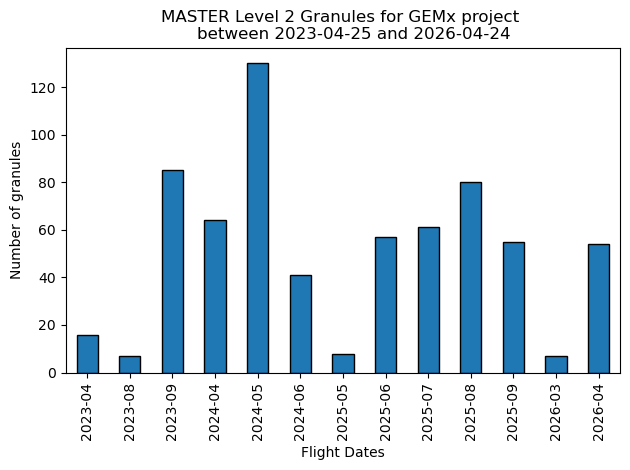

In [7]:
gdf['dt'] = pd.to_datetime(gdf['umm.TemporalExtent.RangeDateTime.BeginningDateTime'])
# montly bins
gdf['month_year'] = gdf['dt'].dt.strftime('%Y-%m')
# Group and count occurrences per interval
gdf.groupby('month_year').size().plot(kind='bar',
                                     edgecolor='black')
plt.xlabel('Flight Dates')
plt.ylabel('Number of granules')
plt.title((
    f"""MASTER Level 2 Granules for {project} project 
    between {gdf['dt'].min().date()} and {gdf['dt'].max().date()}"""
    ))
plt.tight_layout()
plt.show()

As we can see in the above chart, several MASTER flights were flown for GEMx campaign during 2003-2026. 

Now, we can also plot the granule boundaries in a map. 

In [8]:
gdf['year'] = gdf['dt'].dt.strftime('%Y')
gdf[['meta.native-id', 'year', 'geometry']].explore(
    tiles=xyz, attr=attr, column="year",
    style_kwds={"weight": 2, "fillOpacity": 0.1},
)

### Export granule bounds for GIS
The granule information can also be exported to a GeoJSON format and imported into a GIS software.

In [9]:
gdf.to_file("granule.geojson", driver="GeoJSON")

## Open a L2 Granule from the Cloud

MASTER L2 files are in **HDF-5** format. We use `earthaccess.open()` to obtain the file-like objects and read them directly with `xarray`, not needing local download.

In [10]:
# Open the first granule as a cloud-streamed file object
file_objs = earthaccess.open([granules[0]])
granule0 = granules[0].get('umm',[]).get('GranuleUR',[])
print(f"Opened granule: {granule0}")

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Opened granule: MASTERL2_2364900_01_20230425_1733_1751_V02_B200_SV01.hdf5


In [11]:
# xarray can read from a file-like object directly
ds = xarray.open_dataset(file_objs[0], chunks={})
ds

<xarray.Dataset> Size: 193MB
Dimensions:     (phony_dim_0: 6738, phony_dim_1: 716, phony_dim_2: 6)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2
Data variables:
    Emissivity  (phony_dim_0, phony_dim_1, phony_dim_2) float32 116MB dask.array<chunksize=(422, 45, 1), meta=np.ndarray>
    LST         (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
    Lat         (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
    Lon         (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
    QAmap       (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
Attributes:
    Build:              200
    HDF5_Version:       1.14.2
    Software Version:   01
    acquisition_time:   2023-04-25 17:33:04
    description:        Atmospheric Corrected MASTER Land Surface Temperature...
    h5py_version:       3.10.0
    modification_time:  2025-06-03 02:42:53

## Explore the file structure

Let's list all the variables and dimensions of the datasest. The dataset has four variables `Emissivity`, `LST`, `Lat`, `Lon` and `QAmap`.

In [12]:
ds.info()

xarray.Dataset {
dimensions:
	phony_dim_0 = 6738 ;
	phony_dim_1 = 716 ;
	phony_dim_2 = 6 ;

variables:
	float32 Emissivity(phony_dim_0, phony_dim_1, phony_dim_2) ;
		Emissivity:description = Atmospheric Corrected MASTER Emissivity - TES corrected bands ;
		Emissivity:wavelength = [ 8.3   8.61  9.04 10.62 11.32 12.13] ;
		Emissivity:wavelength units = Micrometers ;
	float32 LST(phony_dim_0, phony_dim_1) ;
		LST:band names = LST (K) ;
		LST:description = Temperature (K) - TES LST ;
	float32 Lat(phony_dim_0, phony_dim_1) ;
		Lat:description = Latitude ;
		Lat:units = degrees ;
	float32 Lon(phony_dim_0, phony_dim_1) ;
		Lon:description = Longitude ;
		Lon:units = degrees ;
	float32 QAmap(phony_dim_0, phony_dim_1) ;
		QAmap:description = QA data from TES algorithm: 1 is divergence, 0 is convergence ;

// global attributes:
	:Build = 200 ;
	:HDF5_Version = 1.14.2 ;
	:Software Version = 01 ;
	:acquisition_time = 2023-04-25 17:33:04 ;
	:description = Atmospheric Corrected MASTER Land Surface T

## Assign Coordinates

`Lat` and `Lon` variables provide per-pixel geolocation. Let's assigned them as the coordinates for the dataset so we can use it later for plotting.

In [13]:
ds = ds.assign_coords(lon=ds.Lon, lat=ds.Lat)
ds

<xarray.Dataset> Size: 232MB
Dimensions:     (phony_dim_0: 6738, phony_dim_1: 716, phony_dim_2: 6)
Coordinates:
    lon         (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
    lat         (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2
Data variables:
    Emissivity  (phony_dim_0, phony_dim_1, phony_dim_2) float32 116MB dask.array<chunksize=(422, 45, 1), meta=np.ndarray>
    LST         (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
    Lat         (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
    Lon         (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
    QAmap       (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
Attributes:
    Build:              200
    HDF5_Version:       1.14.2
    Software Version:   01
    acquisition_time:   2023-04-25 17:33:04
    description:        Atmospheric Corrected MASTER Land Surface Temperature...
    h5py_version:       3.10.0
    modification_time:  2025-06-03 02:42:53

## Land Surface Temperature

The LST variable holds per-pixel surface temperature in Kelvin.

In [14]:
ds.LST

<xarray.DataArray 'LST' (phony_dim_0: 6738, phony_dim_1: 716)> Size: 19MB
dask.array<open_dataset-LST, shape=(6738, 716), dtype=float32, chunksize=(211, 45), chunktype=numpy.ndarray>
Coordinates:
    lon      (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
    lat      (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
Dimensions without coordinates: phony_dim_0, phony_dim_1
Attributes:
    band names:   LST (K)
    description:  Temperature (K) - TES LST

Now, Let's print minimum and maximum LST values.

In [15]:
print(f"LST range (K):  {float(ds.LST.min()):.2f} – {float(ds.LST.max()):.2f}")

LST range (K):  292.20 – 433.70


We display the LST variable in degrees Celsius in the following, where surface temperature is represented from cool (dark) to hot (bright).

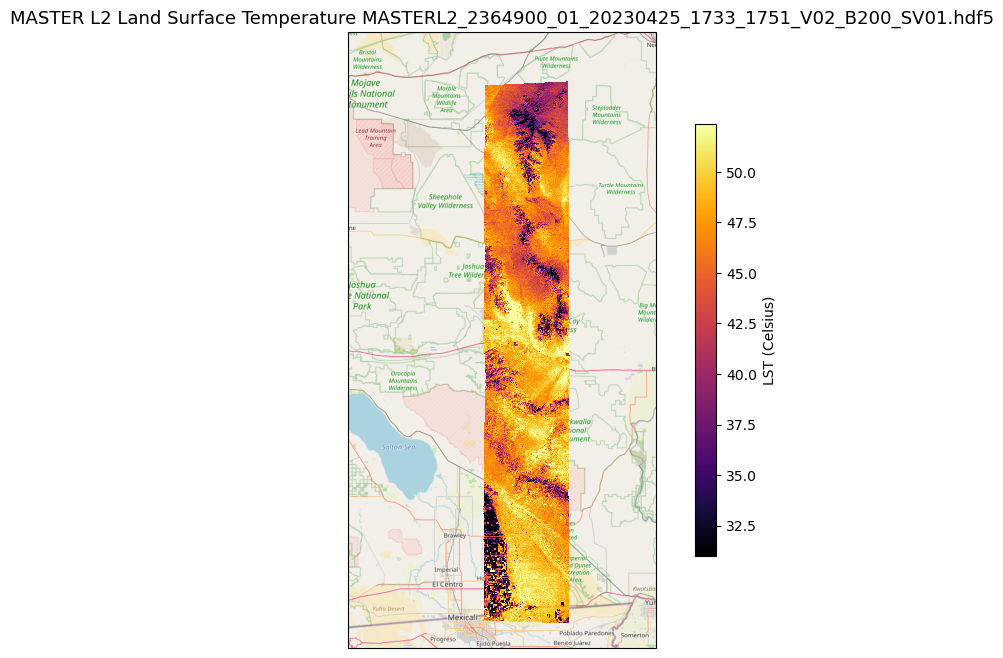

In [16]:
# OpenStreet baselayers
request = cimgt.OSM()

fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=request.crs)

# baselayer zoom
ax.add_image(request, 9)

# K to C
lst_celsius = ds.LST - 273.15 
# setting min max
vmin, vmax = np.nanpercentile(lst_celsius, [2, 98])
im = lst_celsius.plot(
        ax=ax, x='lon', y='lat', 
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(),
        cmap='inferno', add_colorbar=False 
)
ax.set_title(f"MASTER L2 Land Surface Temperature {granule0}", fontsize=13)
fig.colorbar(im, ax=ax, label=f"LST (Celsius)", pad=0.05, shrink=0.7)
plt.show()

## Emissivity

The TES algorithm retrieves emissivity in six thermal infrared (TIR) bands corresponding to spectral regions between 8.3 and 12.11 µm. Emissivity values are dimensionless (0–1), where 1.0 is a perfect blackbody.

In [17]:
ds.Emissivity

<xarray.DataArray 'Emissivity' (phony_dim_0: 6738, phony_dim_1: 716,
                                phony_dim_2: 6)> Size: 116MB
dask.array<open_dataset-Emissivity, shape=(6738, 716, 6), dtype=float32, chunksize=(422, 45, 1), chunktype=numpy.ndarray>
Coordinates:
    lon      (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
    lat      (phony_dim_0, phony_dim_1) float32 19MB dask.array<chunksize=(211, 45), meta=np.ndarray>
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2
Attributes:
    description:       Atmospheric Corrected MASTER Emissivity - TES correcte...
    wavelength:        [ 8.3   8.61  9.04 10.62 11.32 12.13]
    wavelength units:  Micrometers

Let's print minumum and maximum emissivity values for each of the 6 bands

In [18]:
# MASTER TIR emissivity band center wavelengths (µm) for the 6 retrieved bands
wavelengths = ds.Emissivity.attrs.get("wavelength",[])

for i, wl in enumerate(wavelengths):
    emiss = ds.Emissivity.isel({'phony_dim_2': i})
    print(f"Emissivity range for Band {wl} µm:  {float(emiss.min()):.2f} – {float(emiss.max()):.2f}")

Emissivity range for Band 8.3 µm:  0.68 – 1.00
Emissivity range for Band 8.61 µm:  0.69 – 0.99
Emissivity range for Band 9.04 µm:  0.64 – 0.99
Emissivity range for Band 10.62 µm:  0.77 – 0.99
Emissivity range for Band 11.32 µm:  0.67 – 0.99
Emissivity range for Band 12.13 µm:  0.60 – 0.99


Now, let's visualize all six retrieved emissivity bands. Emissivity near 1.0 indicates a near-perfect blackbody. Water and dense vegetation have higher emissivity values. Lower emissivity values are typical of bare soils, rocks, and deserts.

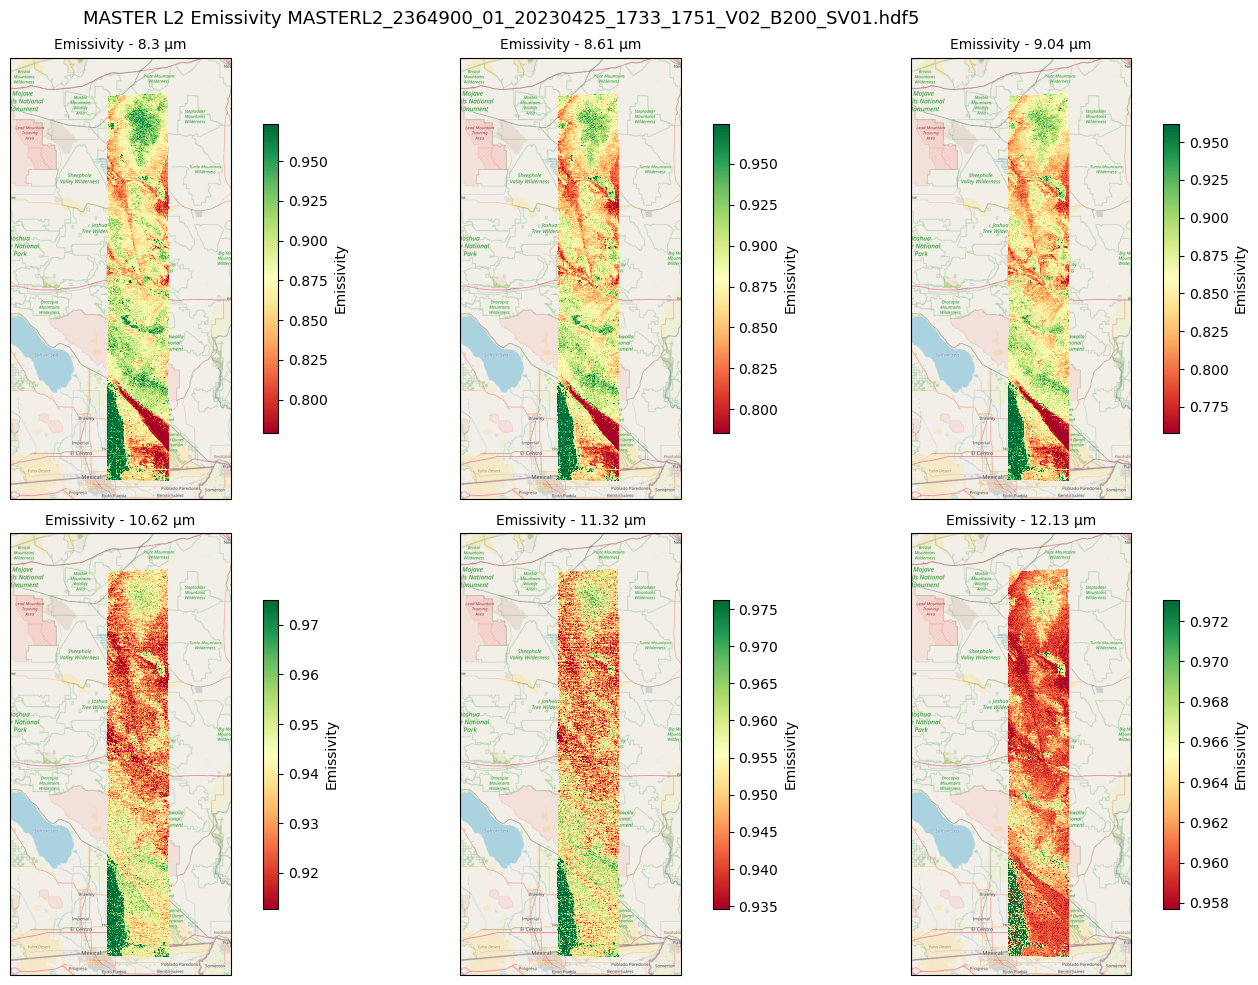

In [19]:
# OpenStreet baselayers
request = cimgt.OSM()

fig, axes = plt.subplots(
    nrows=2, ncols=3, figsize=(16, 10),
    subplot_kw={'projection': request.crs})
axes = axes.flatten()

for i, wl in enumerate(wavelengths):
    emiss = ds.Emissivity.isel({'phony_dim_2': i})
    vmin, vmax = np.nanpercentile(emiss, [2, 98])
    axes[i].add_image(request, 9)

     # plot one band
    im = emiss.plot(
        ax=axes[i], x='lon', y='lat', transform=ccrs.PlateCarree(),
        cmap='RdYlGn', vmin=vmin, vmax=vmax,add_colorbar=False 
    )

    axes[i].set_title(f"Emissivity - {wl} µm", fontsize=10)   
    fig.colorbar(im, ax=axes[i], label="Emissivity", pad=0.05, shrink=0.7)
    

plt.suptitle(f"MASTER L2 Emissivity {granule0}", fontsize=13)
plt.tight_layout()
plt.show()

## Emissivity for a Selected Pixel

We select the pixel with the highest LST (hot, dry surface) and a second pixel with the lowest LST for comparing how emissivity varies across the bands.

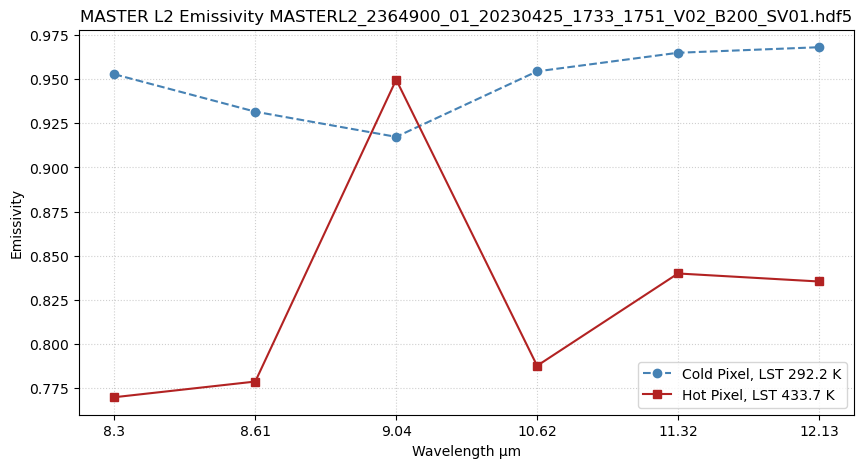

In [20]:
def get_idx(flat_idx, ds_shape, ds_dims):
    """converts flat index into multidimensional index."""
    grid_indices = np.unravel_index(flat_idx, ds_shape)
    return {dim: idx for dim, idx in zip(ds_dims, grid_indices)}

# lst layer
lst = ds.LST.compute()

# flattened index of min value
min_idx = get_idx(lst.argmin(dim=None).item(),
                  lst.shape, lst.dims)
max_idx = get_idx(lst.argmax(dim=None).item(),
                  lst.shape, lst.dims)
                   
plt.figure(figsize=(10, 5))

# emissivity at min max LST plots
ds.Emissivity.isel(min_idx).plot(
    label=f"Cold Pixel, LST {lst[min_idx]:.1f} K", 
    ls="--", marker="o", color="steelblue"
)
ds.Emissivity.isel(max_idx).plot(
    label=f"Hot Pixel, LST {lst[max_idx]:.1f} K", 
    marker="s", color="firebrick"
)
plt.xticks(ticks=np.arange(len(wavelengths)), labels=wavelengths)
plt.xlabel("Wavelength µm")
plt.title(f"MASTER L2 Emissivity {granule0}")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()

For access to the underlying L1B calibrated radiance used to derive these L2 products, see the [MASTER L1B notebook](MASTER_L1_access.ipynb).